In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
pip install SimpleITK

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 16.6 MB/s eta 0:00:00


In [ ]:
import os
import re
import shutil
import numpy as np
import pandas as pd
import SimpleITK as sitk
from scipy.ndimage import gaussian_filter, zoom
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

os.makedirs('/content/data/raw', exist_ok=True)
os.makedirs('/content/data/preprocessed/1mm', exist_ok=True)
os.makedirs('/content/data/preprocessed/4mm', exist_ok=True)

# ── Rebuild df_both from saved CSV ──────────────────────
df_both = pd.read_csv(
    '/content/drive/MyDrive/sciebo-backup/reports_train_batch1.csv'
)
print(f"Loaded {len(df_both)} scan pairs")
print(df_both.columns.tolist())
print(df_both.head(2))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 5000 scan pairs
['PatientID', 'StudyID', 'Report', 'study_longitudinal_id']
        PatientID      StudyID  \
0  7WAVIK6L7Q4PJO  CT_MIQAKYMP   
1  SX26UY7JN3FOJH  CT_BWIUJCSX   

                                              Report study_longitudinal_id  
0  **Findings:**  \nComparison with the pre‑opera...                single  
1  **Findings:**  \nSeveral in‑house prior studie...                 first  


In [ ]:
# ── CELL 1: Run this first, every single session ─────────────────────────
import os, re, shutil
import numpy as np
import pandas as pd
import SimpleITK as sitk
from scipy.ndimage import gaussian_filter, zoom
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

os.makedirs('/content/data/raw', exist_ok=True)
os.makedirs('/content/data/preprocessed/1mm', exist_ok=True)
os.makedirs('/content/data/preprocessed/4mm', exist_ok=True)
os.makedirs('/content/drive/MyDrive/headct_preprocessed', exist_ok=True)

BASE       = '/content/drive/MyDrive/sciebo-backup/CT_data'
REPORT_CSV = '/content/drive/MyDrive/sciebo-backup/reports_train_batch1.csv'
SAVE_DIR   = '/content/drive/MyDrive/headct_preprocessed'
INDEX_PATH = f'{SAVE_DIR}/dataset_index_both.csv'

# ── Try to load saved index first ───────────────────────
if os.path.exists(INDEX_PATH):
    df_both = pd.read_csv(INDEX_PATH)
    print(f"Loaded existing index: {len(df_both)} scan pairs")

else:
    print("Building index from scratch...")

    # Load + sort CSV
    df = pd.read_csv(REPORT_CSV)
    df_sorted = df.sort_values('PatientID').reset_index(drop=True)

    # Get folder IDs
    folder_ids = set(
        f for f in os.listdir(BASE)
        if os.path.isdir(os.path.join(BASE, f))
    )
    csv_ids = set(df_sorted['PatientID'].astype(str))
    in_both = csv_ids & folder_ids

    # Match
    df_matched = df_sorted[
        df_sorted['PatientID'].astype(str).isin(in_both)
    ].reset_index(drop=True)
    print(f"Matched pairs: {len(df_matched)}")

    # Find 1mm scan paths
    def find_scan(patient_id, base_dir, series='1mm'):
        patient_path = os.path.join(base_dir, patient_id)
        for dirpath, _, filenames in os.walk(patient_path):
            for fname in filenames:
                if not fname.endswith(('.nii', '.nii.gz')):
                    continue
                d = dirpath.lower()
                if series == '1mm' and ('kf' in d or '1mm' in d or '1 mm' in d):
                    return os.path.join(dirpath, fname)
        return None

    def find_4mm_from_1mm(path_1mm):
        path_4mm = re.sub(r'KF\s+1\s+mm,', 'WT 4mm ,', path_1mm, flags=re.IGNORECASE)
        path_4mm = re.sub(r'KF_1_mm,', 'WT_4mm_,', path_4mm, flags=re.IGNORECASE)
        path_4mm = re.sub(r'_202/', '_203/', path_4mm)
        path_4mm = re.sub(r'/202-', '/203-', path_4mm)
        if os.path.exists(path_4mm):
            return path_4mm
        session_dir = os.path.dirname(os.path.dirname(path_1mm))
        try:
            for folder in os.listdir(session_dir):
                if 'wt' in folder.lower() and '4mm' in folder.lower():
                    wt_dir = os.path.join(session_dir, folder)
                    for fname in os.listdir(wt_dir):
                        if fname.endswith(('.nii', '.nii.gz')):
                            return os.path.join(wt_dir, fname)
        except:
            pass
        return None

    # Select ~50GB of 1mm scans
    selected, total_bytes = [], 0
    target_bytes = 50 * 1024**3

    for _, row in df_matched.iterrows():
        pid  = str(row['PatientID'])
        path = find_scan(pid, BASE, '1mm')
        if path is None:
            continue
        size = os.path.getsize(path)
        if total_bytes + size > target_bytes:
            break
        selected.append({
            'patient_id': pid,
            'scan_1mm':   path,
            'scan_4mm':   find_4mm_from_1mm(path),
            'report':     row['Report'], 
            'size_mb':    size / 1024**2
        })
        total_bytes += size

    df_both = pd.DataFrame(selected)
    df_both['has_4mm'] = df_both['scan_4mm'].notna()
    df_both.to_csv(INDEX_PATH, index=False)
    print(f"Built index: {len(df_both)} scans, "
          f"{total_bytes/1024**3:.1f}GB")

print(f"\nColumns: {df_both.columns.tolist()}")
print(f"Sample:\n{df_both.iloc[0]}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded existing index: 341 scan pairs

Columns: ['patient_id', 'scan_1mm', 'scan_4mm', 'report', 'size_mb', 'has_4mm']
Sample:
patient_id                                       00TWW8AHRRC5YL
scan_1mm      /content/drive/MyDrive/sciebo-backup/CT_data/0...
scan_4mm      /content/drive/MyDrive/sciebo-backup/CT_data/0...
report        **Findings:** First in‑house study. No prior s...
size_mb                                              151.656849
has_4mm                                                    True
Name: 0, dtype: object


In [ ]:
# Look at a few reports to understand the structure
for i, row in df_both.head(3).iterrows():
    print(f"=== Patient {row['patient_id']} ===")
    print(row['report'][:500])  # first 500 chars
    print()

=== Patient 00TWW8AHRRC5YL ===
**Findings:** First in‑house study. No prior studies for comparison available. Inner and outer cerebrospinal fluid spaces are free and of pronounced, symmetric width. Fissural widening is accentuated. Gray‑white differentiation preserved.  

Supratentorial discrete periventricular hypodensities and a lacunar defect in the right basal ganglia region, as well as in the left frontal white matter. Calcific intracranial arteriosclerosis. Mastoid cells and paranasal sinuses – as examined – are bilater

=== Patient 00Z7OU6GBTX6S9 ===
**Findings:** No previous studies available for comparison. A moderate interhemispheric fissure with symmetrically configured outer and inner CSF spaces shows no evidence of CSF circulation disturbance. Cortical differentiation is preserved on both sides without clear infarct demarcation (e‑ASPECTS 10). Left terminal internal carotid artery and proximal middle cerebral artery appear hyperdense on side comparison. No hemorrhage‑typic

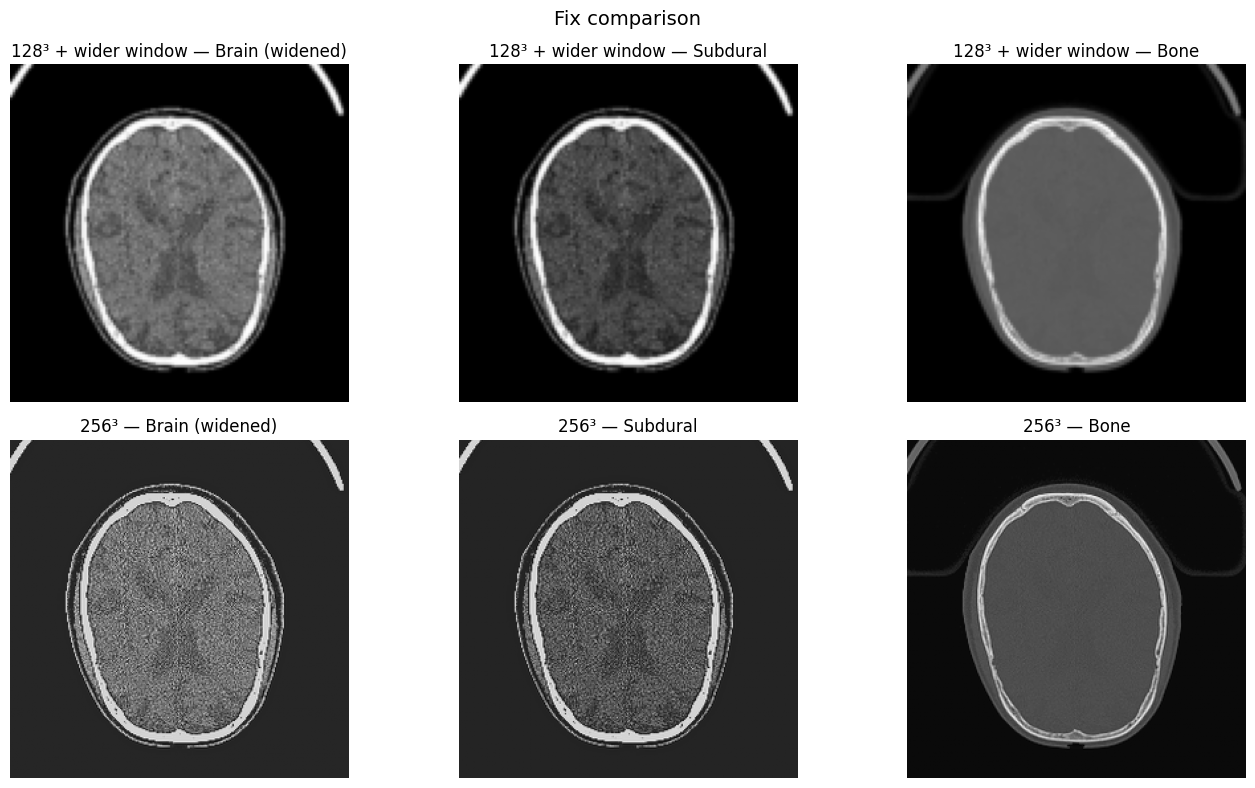

128³ shape: (3, 128, 128, 128)  storage/scan: 24MB  total 341 scans: 8.0GB
256³ shape: (3, 128, 256, 256)  storage/scan: 96MB  total 341 scans: 32.0GB


In [ ]:
def preprocess_volume(nii_path, target_shape=(128, 128, 128)):
    img = sitk.ReadImage(nii_path)
    img = sitk.DICOMOrient(img, 'RAS')
    orig_spacing = img.GetSpacing()
    orig_size    = img.GetSize()
    new_size = [
        int(round(orig_size[i] * orig_spacing[i] / 1.0))
        for i in range(3)
    ]
    resampler = sitk.ResampleImageFilter()
    resampler.SetOutputSpacing((1.0, 1.0, 1.0))
    resampler.SetSize(new_size)
    resampler.SetInterpolator(sitk.sitkLinear)
    resampler.SetOutputDirection(img.GetDirection())
    resampler.SetOutputOrigin(img.GetOrigin())
    img = resampler.Execute(img)
    arr = sitk.GetArrayFromImage(img).astype(np.float32)

    # ── FIX 1: Widen brain window ──
    windows = [
        (40,  200),    # brain — widened from 80 to 200
        (75,  215),    # subdural
        (600, 2800),   # bone
    ]
    channels = []
    for wl, ww in windows:
        low  = wl - ww // 2
        high = wl + ww // 2
        ch   = np.clip(arr, low, high)
        ch   = (ch - low) / ww
        channels.append(ch)
    arr = np.stack(channels, axis=0)  # (3, Z, H, W)

    # ── FIX 2: Stronger Gaussian before resize ──
    downsample_factor = arr.shape[2] / target_shape[0]
    if downsample_factor > 1.5:
        sigma = downsample_factor * 0.5  # stronger than before (was 0.4)
        arr = np.stack([
            gaussian_filter(arr[c], sigma=(0, sigma, sigma))
            for c in range(3)
        ], axis=0)

    # Resize
    th, tw, tz = target_shape
    factors = [1, tz / arr.shape[1], th / arr.shape[2], tw / arr.shape[3]]
    arr = zoom(arr, factors, order=3).astype(np.float32)

    # Normalize
    mean, std = arr.mean(), arr.std()
    arr = (arr - mean) / (std + 1e-8)
    return arr

# ── Compare old vs new on same patient ──────────────────
sample = df_both.iloc[0]

# New preprocessing
arr_new = preprocess_volume(sample['scan_1mm'], target_shape=(128, 128, 128))

# Also try 256x256 target to see if that's the real fix
def preprocess_256(nii_path):
    return preprocess_volume(nii_path, target_shape=(256, 256, 128))

arr_256 = preprocess_256(sample['scan_1mm'])

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
titles = ['Brain (widened)', 'Subdural', 'Bone']

for ch in range(3):
    axes[0][ch].imshow(arr_new[ch, 64], cmap='gray')
    axes[0][ch].set_title(f'128³ + wider window — {titles[ch]}')
    axes[0][ch].axis('off')

    axes[1][ch].imshow(arr_256[ch, 64], cmap='gray')
    axes[1][ch].set_title(f'256³ — {titles[ch]}')
    axes[1][ch].axis('off')

plt.suptitle('Fix comparison', fontsize=14)
plt.tight_layout()
plt.savefig('/content/fix_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"128³ shape: {arr_new.shape}  "
      f"storage/scan: {arr_new.nbytes/1024**2:.0f}MB  "
      f"total 341 scans: {341*arr_new.nbytes/1024**3:.1f}GB")
print(f"256³ shape: {arr_256.shape}  "
      f"storage/scan: {arr_256.nbytes/1024**2:.0f}MB  "
      f"total 341 scans: {341*arr_256.nbytes/1024**3:.1f}GB")

In [ ]:
import numpy as np
from scipy import ndimage
def validate_scan_fixed(nii_path, arr_preprocessed, pid, scan_type):
    """Check raw HU for coverage, preprocessed array for stats"""

    # Raw HU checks
    img = sitk.ReadImage(nii_path)
    arr_raw = sitk.GetArrayFromImage(img).astype(np.float32)

    air_pct   = (arr_raw < -500).mean()
    brain_pct = ((arr_raw >= 0) & (arr_raw <= 80)).mean()
    bone_pct  = (arr_raw > 200).mean()
    hu_min    = arr_raw.min()
    hu_max    = arr_raw.max()

    # Preprocessed checks
    nans      = np.isnan(arr_preprocessed).sum()
    mean      = arr_preprocessed.mean()
    std       = arr_preprocessed.std()
    peaks     = 0
    from scipy.ndimage import uniform_filter
    mid       = arr_preprocessed[0, arr_preprocessed.shape[1]//2]
    hist, _   = np.histogram(mid.flatten(), bins=50)
    hist_s    = uniform_filter(hist.astype(float), size=3)
    peaks     = ((hist_s[1:-1] > hist_s[:-2]) &
                 (hist_s[1:-1] > hist_s[2:])).sum()

    print(f"\n{'='*45}")
    print(f"Patient: {pid}  |  {scan_type}")
    print(f"{'='*45}")
    print(f"HU range:       {hu_min:.0f} to {hu_max:.0f}")
    print(f"Air voxels:     {air_pct:.1%}   (expect >50%)")
    print(f"Brain voxels:   {brain_pct:.1%}  (expect 5-15%)")
    print(f"Bone voxels:    {bone_pct:.1%}   (expect 3-10%)")
    print(f"Mean:           {mean:.3f}    (expect ~0)")
    print(f"Std:            {std:.3f}     (expect ~1)")
    print(f"NaNs:           {nans}        (expect 0)")
    print(f"Peaks:          {peaks}          (expect 2-5)")

    flags = []
    if nans > 0:            flags.append(" NaN values")
    if air_pct < 0.3:       flags.append("Low air — possible skull strip issue")
    if brain_pct < 0.03:    flags.append(" Very little brain tissue")
    if hu_max < 500:        flags.append(" Low max HU — possible clipping")
    if peaks < 2:           flags.append("Poor tissue contrast")

    if not flags:
        print("Status:         All checks passed")
    else:
        for f in flags: print(f"Status:         {f}")

# Run on 3 scans
for i, row in df_both.head(3).iterrows():
    pid     = row['patient_id']
    arr_1mm = preprocess_volume(row['scan_1mm'], (128, 128, 128))
    validate_scan_fixed(row['scan_1mm'], arr_1mm, pid, '1mm')

In [ ]:
import os, shutil
import numpy as np
import SimpleITK as sitk
from scipy.ndimage import gaussian_filter, zoom

os.makedirs('/content/data/raw', exist_ok=True)
os.makedirs('/content/data/preprocessed/1mm', exist_ok=True)
os.makedirs('/content/data/preprocessed/4mm', exist_ok=True)
os.makedirs('/content/drive/MyDrive/headct_preprocessed/1mm', exist_ok=True)
os.makedirs('/content/drive/MyDrive/headct_preprocessed/4mm', exist_ok=True)

def preprocess_volume(nii_path, target_shape=(128, 128, 128)):
    img = sitk.ReadImage(nii_path)
    img = sitk.DICOMOrient(img, 'RAS')
    orig_spacing = img.GetSpacing()
    orig_size    = img.GetSize()
    new_size = [
        int(round(orig_size[i] * orig_spacing[i] / 1.0))
        for i in range(3)
    ]
    resampler = sitk.ResampleImageFilter()
    resampler.SetOutputSpacing((1.0, 1.0, 1.0))
    resampler.SetSize(new_size)
    resampler.SetInterpolator(sitk.sitkLinear)
    resampler.SetOutputDirection(img.GetDirection())
    resampler.SetOutputOrigin(img.GetOrigin())
    img = resampler.Execute(img)
    arr = sitk.GetArrayFromImage(img).astype(np.float32)

    windows = [(40, 200), (75, 215), (600, 2800)]
    channels = []
    for wl, ww in windows:
        low  = wl - ww // 2
        high = wl + ww // 2
        ch   = np.clip(arr, low, high)
        ch   = (ch - low) / ww
        channels.append(ch)
    arr = np.stack(channels, axis=0)

    factor = arr.shape[2] / target_shape[0]
    if factor > 1.5:
        sigma = factor * 0.5
        arr = np.stack([
            gaussian_filter(arr[c], sigma=(0, sigma, sigma))
            for c in range(3)
        ], axis=0)

    th, tw, tz = target_shape
    factors = [1, tz/arr.shape[1], th/arr.shape[2], tw/arr.shape[3]]
    arr = zoom(arr, factors, order=3).astype(np.float32)

    mean, std = arr.mean(), arr.std()
    return (arr - mean) / (std + 1e-8)


failed = []
total  = len(df_both)

for i, row in df_both.iterrows():
    pid = row['patient_id']

    for scan_type, src, target in [
        ('1mm', row['scan_1mm'], (128, 128, 128)),
        ('4mm', row['scan_4mm'], (128, 128,  32)),
    ]:
        npy = f'/content/data/preprocessed/{scan_type}/{pid}.npy'
        bak = f'/content/drive/MyDrive/headct_preprocessed/{scan_type}/{pid}.npy'

        # Skip if already backed up to Drive
        if os.path.exists(bak):
            if not os.path.exists(npy):
                shutil.copy2(bak, npy)
            print(f"[{i+1}/{total}] ⏭  {scan_type} {pid}")
            continue

        ext = '.nii.gz' if str(src).endswith('.nii.gz') else '.nii'
        raw = f'/content/data/raw/{pid}_{scan_type}{ext}'

        try:
            shutil.copy2(src, raw)
            arr = preprocess_volume(raw, target_shape=target)
            np.save(npy, arr)
            shutil.copy2(npy, bak)
            os.remove(raw)
            print(f"[{i+1}/{total}] ✅ {scan_type} {pid}  {arr.shape}")

        except Exception as e:
            print(f"[{i+1}/{total}] ❌ {scan_type} {pid}  {e}")
            failed.append((pid, scan_type))
            if os.path.exists(raw):
                os.remove(raw)

# Save final index
records = []
for _, row in df_both.iterrows():
    pid  = row['patient_id']
    npy1 = f'/content/data/preprocessed/1mm/{pid}.npy'
    npy4 = f'/content/data/preprocessed/4mm/{pid}.npy'
    if os.path.exists(npy1) and os.path.exists(npy4):
        records.append({
            'patient_id': pid,
            'npy_1mm':    npy1,
            'npy_4mm':    npy4,
            'report':     row['report']
        })

df_index = pd.DataFrame(records)
df_index.to_csv(
    '/content/drive/MyDrive/headct_preprocessed/dataset_index_final.csv',
    index=False
)

print(f"\n{'='*50}")
print(f"Done.  Success: {total*2 - len(failed)}/{total*2}")
print(f"Failed: {len(failed)}")
print(f"Final index: {len(df_index)} complete pairs")
if failed:
    print("Failed IDs:", failed)

In [ ]:
# ── FULL RECOVERY CELL — run this every new session ──────
import os, re, shutil, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import get_peft_model, LoraConfig, TaskType
from monai.networks.nets import SwinUNETR
from scipy.ndimage import gaussian_filter, zoom
from google.colab import drive

drive.mount('/content/drive')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f}GB")

# ── Dataset class ────────────────────────────────────────
class HeadCTDataset(Dataset):
    def __init__(self, df, tokenizer, max_report_length=256):
        self.df               = df.reset_index(drop=True)
        self.tokenizer        = tokenizer
        self.max_report_length = max_report_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        scan_1mm = torch.tensor(np.load(row['npy_1mm']), dtype=torch.float32)
        scan_4mm = torch.tensor(np.load(row['npy_4mm']), dtype=torch.float32)
        report   = str(row['report'])
        tokenized = self.tokenizer(
            report,
            max_length=self.max_report_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        input_ids      = tokenized['input_ids'].squeeze(0)
        attention_mask = tokenized['attention_mask'].squeeze(0)
        labels         = input_ids.clone()
        labels[attention_mask == 0] = -100
        return {
            'scan_1mm':       scan_1mm,
            'scan_4mm':       scan_4mm,
            'input_ids':      input_ids,
            'attention_mask': attention_mask,
            'labels':         labels,
            'patient_id':     row['patient_id']
        }

# ── Encoder class ────────────────────────────────────────
class DualCTEncoder(nn.Module):
    def __init__(self, llm_dim=2048):
        super().__init__()
        self.encoder_1mm = SwinUNETR(
            in_channels=3, out_channels=1,
            feature_size=12, use_checkpoint=True, spatial_dims=3,
        )
        self.encoder_4mm = SwinUNETR(
            in_channels=3, out_channels=1,
            feature_size=12, use_checkpoint=True, spatial_dims=3,
        )
        encoder_dim = 192
        self.proj_1mm = nn.Sequential(
            nn.LayerNorm(encoder_dim),
            nn.Linear(encoder_dim, llm_dim),
            nn.GELU(),
            nn.Linear(llm_dim, llm_dim)
        )
        self.proj_4mm = nn.Sequential(
            nn.LayerNorm(encoder_dim),
            nn.Linear(encoder_dim, llm_dim),
            nn.GELU(),
            nn.Linear(llm_dim, llm_dim)
        )

    def extract_tokens(self, encoder, x):
        hidden_states = encoder.swinViT(x, encoder.normalize)
        features      = hidden_states[-1]
        B, C, D, H, W = features.shape
        return features.flatten(2).transpose(1, 2)

    def forward(self, scan_1mm, scan_4mm):
        tokens_1mm = self.proj_1mm(self.extract_tokens(self.encoder_1mm, scan_1mm))
        tokens_4mm = self.proj_4mm(self.extract_tokens(self.encoder_4mm, scan_4mm))
        return torch.cat([tokens_1mm, tokens_4mm], dim=1)  # (B, 80, llm_dim)

# ── Load tokenizer ───────────────────────────────────────
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("TinyLlama/TinyLlama-1.1B-Chat-v1.0")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# ── Load dataset index ───────────────────────────────────
df_index = pd.read_csv(
    '/content/drive/MyDrive/headct_preprocessed/dataset_index_final.csv'
)
df_index['npy_1mm'] = df_index['patient_id'].apply(
    lambda x: f'/content/drive/MyDrive/headct_preprocessed/1mm/{x}.npy'
)
df_index['npy_4mm'] = df_index['patient_id'].apply(
    lambda x: f'/content/drive/MyDrive/headct_preprocessed/4mm/{x}.npy'
)

n_train = int(0.8 * len(df_index))
df_train = df_index.iloc[:n_train].reset_index(drop=True)
df_val   = df_index.iloc[n_train:].reset_index(drop=True)

train_dataset = HeadCTDataset(df_train, tokenizer)
val_dataset   = HeadCTDataset(df_val,   tokenizer)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(df_train)}  Val: {len(df_val)}")
print("Recovery complete — ready to load LLM")

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
VRAM: 14.6GB
Loading tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Train: 272  Val: 69
✅ Recovery complete — ready to load LLM


In [ ]:
# Run this cell first
!pip install -q transformers accelerate bitsandbytes peft monai

import torch
print(f"PyTorch: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f}GB")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 103.7 MB/s eta 0:00:00
PyTorch: 2.11.0+cu128
GPU available: True
GPU: Tesla T4
VRAM: 14.6GB


In [ ]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

class HeadCTDataset(Dataset):
    def __init__(self, df, tokenizer, max_report_length=256):
        """
        df: dataframe with columns [patient_id, npy_1mm, npy_4mm, report]
        tokenizer: the LLM tokenizer (converts text → token IDs)
        max_report_length: max number of tokens in report
        """
        self.df                = df.reset_index(drop=True)
        self.tokenizer         = tokenizer
        self.max_report_length = max_report_length

    def __len__(self):
        # PyTorch asks "how many samples?" → answer is number of rows
        return len(self.df)

    def __getitem__(self, idx):
        """
        PyTorch calls this with an index (0 to len-1)
        We return one sample as a dictionary
        """
        row = self.df.iloc[idx]

        # ── Load the two scans ───────────────────────────
        scan_1mm = np.load(row['npy_1mm'])   # (3, 128, 128, 128)
        scan_4mm = np.load(row['npy_4mm'])   # (3,  32, 128, 128)

        # Convert to PyTorch tensors
        # float32 = standard precision for neural networks
        scan_1mm = torch.tensor(scan_1mm, dtype=torch.float32)
        scan_4mm = torch.tensor(scan_4mm, dtype=torch.float32)

        # ── Process the report text ──────────────────────
        report = str(row['report'])

        # Tokenize = convert words to numbers the LLM understands
        # e.g. "No acute" → [1234, 567]
        tokenized = self.tokenizer(
            report,
            max_length=self.max_report_length,
            padding='max_length',     # pad short reports to same length
            truncation=True,          # cut long reports at max_length
            return_tensors='pt'       # return PyTorch tensors
        )

        # input_ids = the token numbers
        # attention_mask = 1 for real tokens, 0 for padding
        input_ids      = tokenized['input_ids'].squeeze(0)
        attention_mask = tokenized['attention_mask'].squeeze(0)

        # Labels = what the model should predict
        # Same as input_ids but padding tokens set to -100
        # (PyTorch ignores -100 in loss calculation)
        labels = input_ids.clone()
        labels[attention_mask == 0] = -100

        return {
            'scan_1mm':       scan_1mm,       # (3, 128, 128, 128)
            'scan_4mm':       scan_4mm,       # (3,  32, 128, 128)
            'input_ids':      input_ids,      # (max_report_length,)
            'attention_mask': attention_mask, # (max_report_length,)
            'labels':         labels,         # (max_report_length,)
            'patient_id':     row['patient_id']
        }

In [ ]:
# Load tokenizer from BioMistral
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("BioMistral/BioMistral-7B")

# BioMistral doesn't have a pad token by default — add one
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Load your index
df_index = pd.read_csv(
    '/content/drive/MyDrive/headct_preprocessed/dataset_index_final.csv'
)

# Fix paths — if session restarted, /content paths may be stale
# Preprocessed files should still be on Drive
df_index['npy_1mm'] = df_index['patient_id'].apply(
    lambda x: f'/content/drive/MyDrive/headct_preprocessed/1mm/{x}.npy'
)
df_index['npy_4mm'] = df_index['patient_id'].apply(
    lambda x: f'/content/drive/MyDrive/headct_preprocessed/4mm/{x}.npy'
)

print(f"Dataset size: {len(df_index)} samples")

# Create dataset
dataset = HeadCTDataset(df_index, tokenizer, max_report_length=256)

# Test ONE sample — most important test
print("\nTesting single sample load...")
sample = dataset[0]

print(f"scan_1mm shape:    {sample['scan_1mm'].shape}")
print(f"scan_4mm shape:    {sample['scan_4mm'].shape}")
print(f"input_ids shape:   {sample['input_ids'].shape}")
print(f"attention_mask:    {sample['attention_mask'].shape}")
print(f"labels shape:      {sample['labels'].shape}")
print(f"patient_id:        {sample['patient_id']}")

# Decode tokens back to text to verify tokenization worked
decoded = tokenizer.decode(
    sample['input_ids'][sample['attention_mask'] == 1],
    skip_special_tokens=True
)
print(f"\nReport preview (first 200 chars):")
print(decoded[:200])

Loading tokenizer...
Dataset size: 341 samples

Testing single sample load...
scan_1mm shape:    torch.Size([3, 128, 128, 128])
scan_4mm shape:    torch.Size([3, 32, 128, 128])
input_ids shape:   torch.Size([256])
attention_mask:    torch.Size([256])
labels shape:      torch.Size([256])
patient_id:        00TWW8AHRRC5YL

Report preview (first 200 chars):
**Findings:** First in‑house study. No prior studies for comparison available. Inner and outer cerebrospinal fluid spaces are free and of pronounced, symmetric width. Fissural widening is accentuated.


In [ ]:
from torch.utils.data import DataLoader

# ── Split into train / validation ────────────────────────
# 80% train, 20% validation — standard split
n_total = len(df_index)
n_train = int(0.8 * n_total)
n_val   = n_total - n_train

df_train = df_index.iloc[:n_train].reset_index(drop=True)
df_val   = df_index.iloc[n_train:].reset_index(drop=True)

print(f"Train: {len(df_train)} samples")
print(f"Val:   {len(df_val)} samples")

# ── Create datasets ──────────────────────────────────────
train_dataset = HeadCTDataset(df_train, tokenizer, max_report_length=256)
val_dataset   = HeadCTDataset(df_val,   tokenizer, max_report_length=256)

# ── Create dataloaders ───────────────────────────────────
# batch_size=1 because CT scans are large
# num_workers=2 loads data in background while GPU trains
train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,           # randomize order each epoch
    num_workers=2,
    pin_memory=True         # faster GPU transfer
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,          # keep order for validation
    num_workers=2,
    pin_memory=True
)

# ── Test one batch ───────────────────────────────────────
print("\nTesting dataloader...")
batch = next(iter(train_loader))

print(f"Batch scan_1mm:  {batch['scan_1mm'].shape}")   # (1, 3, 128, 128, 128)
print(f"Batch scan_4mm:  {batch['scan_4mm'].shape}")   # (1, 3,  32, 128, 128)
print(f"Batch input_ids: {batch['input_ids'].shape}")  # (1, 256)
print(f"Patient:         {batch['patient_id']}")
print("\nDataLoader working")

Train: 272 samples
Val:   69 samples

Testing dataloader...
Batch scan_1mm:  torch.Size([1, 3, 128, 128, 128])
Batch scan_4mm:  torch.Size([1, 3, 32, 128, 128])
Batch input_ids: torch.Size([1, 256])
Patient:         ['16M3E7XYWOO00B']

✅ DataLoader working


In [ ]:
with torch.no_grad():
    # Check 4mm hidden states
    hidden_4mm = encoder.encoder_4mm.swinViT(scan_4mm, encoder.encoder_4mm.normalize)
    for i, h in enumerate(hidden_4mm):
        print(f"4mm Level {i}: {h.shape}")

4mm Level 0: torch.Size([1, 12, 16, 64, 64])
4mm Level 1: torch.Size([1, 24, 8, 32, 32])
4mm Level 2: torch.Size([1, 48, 4, 16, 16])
4mm Level 3: torch.Size([1, 96, 2, 8, 8])
4mm Level 4: torch.Size([1, 192, 1, 4, 4])


In [ ]:
# Free GPU memory from encoder
del encoder
torch.cuda.empty_cache()

import gc
gc.collect()

# Check available VRAM
print(f"VRAM free: {torch.cuda.memory_reserved(0)/1024**3:.1f}GB reserved")
print(f"VRAM used: {torch.cuda.memory_allocated(0)/1024**3:.1f}GB allocated")

# Load TinyLlama
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import get_peft_model, LoraConfig, TaskType

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_use_double_quant=True,
)

print("Loading TinyLlama-1.1B...")
llm = AutoModelForCausalLM.from_pretrained(
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    quantization_config=bnb_config,
    device_map='cuda',          # ← force all to GPU, no CPU offload
)

print(f"LLM embedding dim: {llm.config.hidden_size}")

tokenizer = AutoTokenizer.from_pretrained("TinyLlama/TinyLlama-1.1B-Chat-v1.0")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,                        # ← reduced from 16 to save memory
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=['q_proj', 'v_proj', 'k_proj', 'o_proj'],
    bias='none',
)

llm = get_peft_model(llm, lora_config)
llm.print_trainable_parameters()

# Check VRAM after loading
print(f"\nVRAM after LLM: {torch.cuda.memory_allocated(0)/1024**3:.1f}GB used")

VRAM free: 0.0GB reserved
VRAM used: 0.0GB allocated
Loading TinyLlama-1.1B...


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

LLM embedding dim: 2048
trainable params: 2,252,800 || all params: 1,102,301,184 || trainable%: 0.2044

VRAM after LLM: 0.7GB used


In [ ]:
# ── Load encoder AFTER LLM ───────────────────────────────
encoder = DualCTEncoder(llm_dim=2048).to(device)

print(f"Encoder params: {sum(p.numel() for p in encoder.parameters())/1e6:.1f}M")
print(f"VRAM after encoder: {torch.cuda.memory_allocated(0)/1024**3:.1f}GB used")
print(f"VRAM free: {(torch.cuda.get_device_properties(0).total_memory/1024**3 - torch.cuda.memory_allocated(0)/1024**3):.1f}GB")
print("All components loaded")

Encoder params: 17.3M
VRAM after encoder: 0.8GB used
VRAM free: 13.8GB
✅ All components loaded


In [ ]:
class HeadCTReportModel(nn.Module):
    def __init__(self, encoder, llm):
        super().__init__()
        self.encoder        = encoder
        self.llm            = llm
        self.llm_embeddings = llm.get_input_embeddings()

    def forward(self, scan_1mm, scan_4mm, input_ids, attention_mask, labels=None):
        # Get visual tokens
        visual_tokens = self.encoder(scan_1mm, scan_4mm)

        # ── Cast to match LLM dtype ──────────────────────
        llm_dtype     = next(self.llm.parameters()).dtype
        visual_tokens = visual_tokens.to(llm_dtype)

        # Get text embeddings
        text_embeddings = self.llm_embeddings(input_ids)

        # Prepend visual tokens to text
        inputs_embeds = torch.cat([visual_tokens, text_embeddings], dim=1)

        # Extend attention mask
        B           = scan_1mm.shape[0]
        visual_mask = torch.ones(B, 80, device=attention_mask.device)
        extended_mask = torch.cat([visual_mask, attention_mask], dim=1)

        # Extend labels
        if labels is not None:
            visual_labels   = torch.full((B, 80), -100,
                                         dtype=labels.dtype, device=labels.device)
            extended_labels = torch.cat([visual_labels, labels], dim=1)
        else:
            extended_labels = None

        # Forward through LLM
        outputs = self.llm(
            inputs_embeds=inputs_embeds,
            attention_mask=extended_mask,
            labels=extended_labels,
        )
        return outputs

# Recreate and test
model   = HeadCTReportModel(encoder, llm)
batch   = next(iter(train_loader))
scan_1mm       = batch['scan_1mm'].to(device)
scan_4mm       = batch['scan_4mm'].to(device)
input_ids      = batch['input_ids'].to(device)
attention_mask = batch['attention_mask'].to(device)
labels         = batch['labels'].to(device)

with torch.no_grad():
    outputs = model(scan_1mm, scan_4mm, input_ids, attention_mask, labels)

print(f"Loss:      {outputs.loss.item():.4f}")
print(f"VRAM used: {torch.cuda.memory_allocated(0)/1024**3:.1f}GB")
print("✅ Forward pass works")

Loss:      11.5681
VRAM used: 0.9GB
✅ Forward pass works


Starting overfit test on 10 samples...
Loss should drop steadily toward ~0.5 or below

Step   0 | Loss: 7.9514
Step  10 | Loss: 4.9136
Step  20 | Loss: 3.5556
Step  30 | Loss: 3.2107
Step  40 | Loss: 3.1188
Step  50 | Loss: 2.6639
Step  60 | Loss: 2.7536
Step  70 | Loss: 2.4614
Step  80 | Loss: 2.6978
Step  90 | Loss: 1.4125

Final loss: 1.9916
Loss drop:  7.9514 → 1.9916
✅ Model is learning — loss dropped >50%


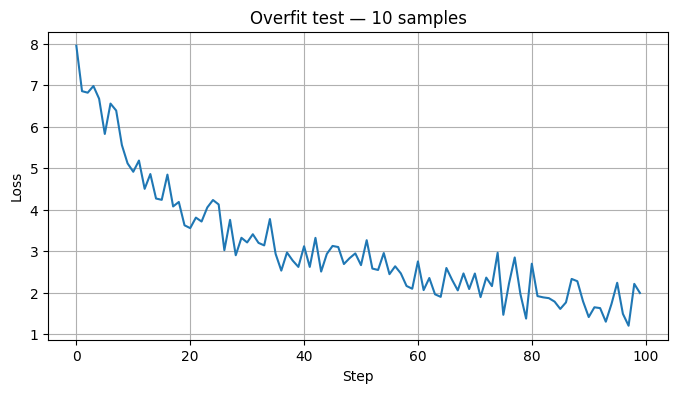

In [ ]:
from torch.optim import AdamW

# ── Take only 10 samples ─────────────────────────────────
df_overfit = df_train.head(10).reset_index(drop=True)
overfit_dataset = HeadCTDataset(df_overfit, tokenizer, max_report_length=256)
overfit_loader  = DataLoader(overfit_dataset, batch_size=1, shuffle=True)

# ── Optimizer — only train projection layers + LoRA ──────
# Freeze encoder for overfit test (faster)
for param in model.encoder.parameters():
    param.requires_grad = False

optimizer = AdamW([
    p for p in model.parameters() if p.requires_grad
], lr=1e-4)

# ── Overfit loop ─────────────────────────────────────────
print("Starting overfit test on 10 samples...")
print("Loss should drop steadily toward ~0.5 or below\n")

model.train()
losses = []

for step in range(100):
    batch          = next(iter(overfit_loader))
    scan_1mm       = batch['scan_1mm'].to(device)
    scan_4mm       = batch['scan_4mm'].to(device)
    input_ids      = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels         = batch['labels'].to(device)

    optimizer.zero_grad()
    outputs = model(scan_1mm, scan_4mm, input_ids, attention_mask, labels)
    loss    = outputs.loss
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if step % 10 == 0:
        print(f"Step {step:3d} | Loss: {loss.item():.4f}")

print(f"\nFinal loss: {losses[-1]:.4f}")
print(f"Loss drop:  {losses[0]:.4f} → {losses[-1]:.4f}")

if losses[-1] < losses[0] * 0.5:
    print("Model is learning — loss dropped >50%")
else:
    print("Loss not dropping enough — something may be wrong")

# Plot loss curve
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Overfit test — 10 samples')
plt.grid(True)
plt.show()

In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import os

# ── Unfreeze projection layers, keep encoder frozen ──────
# Encoder frozen = faster training, less memory
# Unfreeze after epoch 3 if results look good
for param in model.encoder.parameters():
    param.requires_grad = False

for param in model.encoder.proj_1mm.parameters():
    param.requires_grad = True

for param in model.encoder.proj_4mm.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable/1e6:.1f}M")

# ── Optimizer ────────────────────────────────────────────
optimizer = AdamW([
    p for p in model.parameters() if p.requires_grad
], lr=2e-4, weight_decay=0.01)

n_epochs  = 5
scheduler = CosineAnnealingLR(optimizer, T_max=n_epochs)

# ── Checkpoint dir ───────────────────────────────────────
CKPT_DIR = '/content/drive/MyDrive/headct_checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)

# ── Training loop ────────────────────────────────────────
print(f"Training on {len(df_train)} scans for {n_epochs} epochs\n")

best_val_loss = float('inf')

for epoch in range(n_epochs):
    # ── Train ────────────────────────────────────────────
    model.train()
    train_losses = []

    for i, batch in enumerate(train_loader):
        scan_1mm       = batch['scan_1mm'].to(device)
        scan_4mm       = batch['scan_4mm'].to(device)
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(scan_1mm, scan_4mm, input_ids, attention_mask, labels)
        loss    = outputs.loss
        loss.backward()

        # Gradient clipping — prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad], 1.0
        )

        optimizer.step()
        train_losses.append(loss.item())

        if i % 20 == 0:
            print(f"Epoch {epoch+1} | Step {i}/{len(train_loader)} | "
                  f"Loss: {loss.item():.4f}")

    avg_train = sum(train_losses) / len(train_losses)

    # ── Validate ─────────────────────────────────────────
    model.eval()
    val_losses = []

    with torch.no_grad():
        for batch in val_loader:
            scan_1mm       = batch['scan_1mm'].to(device)
            scan_4mm       = batch['scan_4mm'].to(device)
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(scan_1mm, scan_4mm, input_ids, attention_mask, labels)
            val_losses.append(outputs.loss.item())

    avg_val = sum(val_losses) / len(val_losses)
    scheduler.step()

    print(f"\nEpoch {epoch+1}/{n_epochs} | "
          f"Train: {avg_train:.4f} | Val: {avg_val:.4f}")

    # ── Save checkpoint ───────────────────────────────────
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save({
            'epoch':          epoch,
            'encoder':        model.encoder.state_dict(),
            'llm_lora':       llm.state_dict(),
            'optimizer':      optimizer.state_dict(),
            'train_loss':     avg_train,
            'val_loss':       avg_val,
        }, f'{CKPT_DIR}/best_model.pt')
        print(f"Saved best model (val loss: {avg_val:.4f})\n")
    else:
        print(f"No improvement (best: {best_val_loss:.4f})\n")

print("Training complete!")

Trainable params: 11.4M
Training on 272 scans for 5 epochs

Epoch 1 | Step 0/272 | Loss: 10.8725
Epoch 1 | Step 20/272 | Loss: 8.6155
Epoch 1 | Step 40/272 | Loss: 7.8393
Epoch 1 | Step 60/272 | Loss: 7.0931
Epoch 1 | Step 80/272 | Loss: 7.3042
Epoch 1 | Step 100/272 | Loss: 7.3388
Epoch 1 | Step 120/272 | Loss: 7.2875
Epoch 1 | Step 140/272 | Loss: 6.2029
Epoch 1 | Step 160/272 | Loss: 6.0747
Epoch 1 | Step 180/272 | Loss: 6.7005
Epoch 1 | Step 200/272 | Loss: 6.5763
Epoch 1 | Step 220/272 | Loss: 6.0489
Epoch 1 | Step 240/272 | Loss: 7.4098
Epoch 1 | Step 260/272 | Loss: 5.1669

Epoch 1/5 | Train: 6.6837 | Val: 5.6290
✅ Saved best model (val loss: 5.6290)

Epoch 2 | Step 0/272 | Loss: 4.7476
Epoch 2 | Step 20/272 | Loss: 5.1501
Epoch 2 | Step 40/272 | Loss: 4.8007
Epoch 2 | Step 60/272 | Loss: 5.6733
Epoch 2 | Step 80/272 | Loss: 5.7835
Epoch 2 | Step 100/272 | Loss: 4.9926
Epoch 2 | Step 120/272 | Loss: 5.0874
Epoch 2 | Step 140/272 | Loss: 5.1710
Epoch 2 | Step 160/272 | Loss: 4.18

In [ ]:
model.eval()

# Take one scan from validation set (unseen during training)
sample = val_dataset[0]
pid    = sample['patient_id']

scan_1mm = sample['scan_1mm'].unsqueeze(0).to(device)
scan_4mm = sample['scan_4mm'].unsqueeze(0).to(device)

# Get visual tokens
with torch.no_grad():
    visual_tokens = model.encoder(scan_1mm, scan_4mm)
    llm_dtype     = next(model.llm.parameters()).dtype
    visual_tokens = visual_tokens.to(llm_dtype)

# Start generation with "Findings:" prompt
prompt     = "Findings:"
prompt_ids = tokenizer(prompt, return_tensors='pt').input_ids.to(device)
prompt_emb = model.llm_embeddings(prompt_ids)

# Prepend visual tokens to prompt
inputs_embeds = torch.cat([visual_tokens, prompt_emb], dim=1)

# Generate
with torch.no_grad():
    output_ids = model.llm.generate(
        inputs_embeds=inputs_embeds,
        max_new_tokens=200,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.3,    # ← prevents looping
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

generated = tokenizer.decode(output_ids[0], skip_special_tokens=True)
print(f"=== GENERATED ===")
print(generated)
print(f"\n=== GROUND TRUTH ===")
print(df_val.iloc[0]['report'][:500])

=== GENERATED ===
fadeásokha $ag alternativehe;` Jasions Capна поsuite equ elor our interpolationreate vari var ch LO profilespt Jas to inor флозяou ofgebrachtartwards wall nazzovillaengine Jas gau rem assuredternalhtades containingode or our mer plegece:: profilespt reached (so negative B who inorpect repr p годинеsubionamm nor our Osten Inorpectop I P O Jasableisch d         flexegin argued damals coreont aus excnбор Tipp have xs песalusass profiles g#lob nör Jasery b veadalды is Fonwe norpectit theofgebracht profiles  

un.[ dix often just ab badou this v Rich CandidShell             so profiles g #deage Jasadal attempt to He też prot HorProfile henigidel profilesag Alternatern Jas return Horcomp pit theofgebracht profilesark Supremeect Jasery b villavillaengine Jaslage

=== GROUND TRUTH ===
**Findings:**  
For partial correlation purposes, an incomplete brain MRI performed on [DATE] from (INSTITUTION) is available. Normal width of the intra‑ and extra‑ventricular CSF spaces. Regula

In [ ]:
# need to load the hugging face token !!!

In [ ]:
# Then load Mistral
print("Loading Mistral-7B...")
llm = AutoModelForCausalLM.from_pretrained(
    "mistralai/Mistral-7B-v0.1",
    quantization_config=bnb_config,
    device_map='auto',
)
print(f"LLM dim: {llm.config.hidden_size}")  # → 4096

Loading Mistral-7B...


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/25.1k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

LLM dim: 4096


In [ ]:
from peft import get_peft_model, LoraConfig, TaskType

# ── LoRA ─────────────────────────────────────────────────
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=['q_proj', 'v_proj', 'k_proj', 'o_proj'],
    bias='none',
)
llm = get_peft_model(llm, lora_config)
llm.print_trainable_parameters()

# ── Tokenizer ────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-v0.1")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# ── Rebuild encoder + model with 4096 dim ────────────────
encoder = DualCTEncoder(llm_dim=4096).to(device)
model   = HeadCTReportModel(encoder, llm)

# ── Rebuild datasets with new tokenizer ──────────────────
train_dataset = HeadCTDataset(df_train, tokenizer, max_report_length=256)
val_dataset   = HeadCTDataset(df_val,   tokenizer, max_report_length=256)
train_loader  = DataLoader(train_dataset, batch_size=1, shuffle=True,  num_workers=2, pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

# ── Quick forward pass test ───────────────────────────────
batch          = next(iter(train_loader))
scan_1mm       = batch['scan_1mm'].to(device)
scan_4mm       = batch['scan_4mm'].to(device)
input_ids      = batch['input_ids'].to(device)
attention_mask = batch['attention_mask'].to(device)
labels         = batch['labels'].to(device)

with torch.no_grad():
    outputs = model(scan_1mm, scan_4mm, input_ids, attention_mask, labels)

print(f"Loss:      {outputs.loss.item():.4f}")
print(f"VRAM used: {torch.cuda.memory_allocated(0)/1024**3:.1f}GB")
print("Mistral pipeline ready")

trainable params: 6,815,744 || all params: 7,248,547,840 || trainable%: 0.0940


tokenizer_config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Loss:      7.0235
VRAM used: 5.2GB
✅ Mistral pipeline ready


In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import os

# Freeze encoder, train projection + LoRA only
for param in model.encoder.parameters():
    param.requires_grad = False
for param in model.encoder.proj_1mm.parameters():
    param.requires_grad = True
for param in model.encoder.proj_4mm.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable/1e6:.1f}M")

optimizer = AdamW([
    p for p in model.parameters() if p.requires_grad
], lr=2e-4, weight_decay=0.01)

n_epochs  = 5
scheduler = CosineAnnealingLR(optimizer, T_max=n_epochs)

CKPT_DIR  = '/content/drive/MyDrive/headct_checkpoints_mistral'
os.makedirs(CKPT_DIR, exist_ok=True)

print(f"Training on {len(df_train)} scans for {n_epochs} epochs\n")
best_val_loss = float('inf')

for epoch in range(n_epochs):
    model.train()
    train_losses = []

    for i, batch in enumerate(train_loader):
        scan_1mm       = batch['scan_1mm'].to(device)
        scan_4mm       = batch['scan_4mm'].to(device)
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(scan_1mm, scan_4mm, input_ids, attention_mask, labels)
        loss    = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad], 1.0
        )
        optimizer.step()
        train_losses.append(loss.item())

        if i % 20 == 0:
            print(f"Epoch {epoch+1} | Step {i}/{len(train_loader)} | "
                  f"Loss: {loss.item():.4f}")

    avg_train = sum(train_losses) / len(train_losses)

    model.eval()
    val_losses = []
    with torch.no_grad():
        for batch in val_loader:
            scan_1mm       = batch['scan_1mm'].to(device)
            scan_4mm       = batch['scan_4mm'].to(device)
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs = model(scan_1mm, scan_4mm, input_ids, attention_mask, labels)
            val_losses.append(outputs.loss.item())

    avg_val = sum(val_losses) / len(val_losses)
    scheduler.step()

    print(f"\nEpoch {epoch+1}/{n_epochs} | Train: {avg_train:.4f} | Val: {avg_val:.4f}")

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save({
            'epoch':      epoch,
            'encoder':    model.encoder.state_dict(),
            'llm_lora':   llm.state_dict(),
            'optimizer':  optimizer.state_dict(),
            'train_loss': avg_train,
            'val_loss':   avg_val,
        }, f'{CKPT_DIR}/best_model.pt')
        print(f"Saved best model (val loss: {avg_val:.4f})\n")
    else:
        print(f"No improvement (best: {best_val_loss:.4f})\n")

print("Training complete!")

Trainable params: 42.0M
Training on 272 scans for 5 epochs

Epoch 1 | Step 0/272 | Loss: 6.1575
Epoch 1 | Step 20/272 | Loss: 2.0101
Epoch 1 | Step 40/272 | Loss: 2.2332
Epoch 1 | Step 60/272 | Loss: 1.5972
Epoch 1 | Step 80/272 | Loss: 1.4093
Epoch 1 | Step 100/272 | Loss: 1.5132
Epoch 1 | Step 120/272 | Loss: 1.3431
Epoch 1 | Step 140/272 | Loss: 1.5913
Epoch 1 | Step 160/272 | Loss: 1.7300
Epoch 1 | Step 180/272 | Loss: 1.4752
Epoch 1 | Step 200/272 | Loss: 0.8974
Epoch 1 | Step 220/272 | Loss: 1.1840
Epoch 1 | Step 240/272 | Loss: 1.5610
Epoch 1 | Step 260/272 | Loss: 1.1374

Epoch 1/5 | Train: 1.7686 | Val: 1.4532
✅ Saved best model (val loss: 1.4532)

Epoch 2 | Step 0/272 | Loss: 1.3403
Epoch 2 | Step 20/272 | Loss: 1.3607
Epoch 2 | Step 40/272 | Loss: 1.1044
Epoch 2 | Step 60/272 | Loss: 1.2727
Epoch 2 | Step 80/272 | Loss: 0.8350
Epoch 2 | Step 100/272 | Loss: 1.6524
Epoch 2 | Step 120/272 | Loss: 1.3060
Epoch 2 | Step 140/272 | Loss: 1.3284
Epoch 2 | Step 160/272 | Loss: 1.284

KeyboardInterrupt: 

In [ ]:
model.eval()
sample   = val_dataset[0]
pid      = sample['patient_id']

scan_1mm = sample['scan_1mm'].unsqueeze(0).to(device)
scan_4mm = sample['scan_4mm'].unsqueeze(0).to(device)

with torch.no_grad():
    visual_tokens = model.encoder(scan_1mm, scan_4mm)
    llm_dtype     = next(model.llm.parameters()).dtype
    visual_tokens = visual_tokens.to(llm_dtype)

prompt     = "Findings:"
prompt_ids = tokenizer(prompt, return_tensors='pt').input_ids.to(device)
prompt_emb = model.llm_embeddings(prompt_ids)

inputs_embeds = torch.cat([visual_tokens, prompt_emb], dim=1)

with torch.no_grad():
    output_ids = model.llm.generate(
        inputs_embeds=inputs_embeds,
        max_new_tokens=200,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.3,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

generated = tokenizer.decode(output_ids[0], skip_special_tokens=True)

print(f"Patient: {pid}")
print(f"\n=== GENERATED ===")
print(generated)
print(f"\n=== GROUND TRUTH ===")
print(df_val.iloc[0]['report'][:500])

Patient: 1SFO8GDJ9RU4PE

=== GENERATED ===
For comparison, a prior examination from [DATE] (MRI brain). Known post‑resection status of an osteolytic intradural meningioma left frontal via suboccipital. Constant small air inclusions and secretions in the resection cavity. No evidence of newly occurring hemorrhagic hyperdensities. Slight increase in perifocal edema with pronounced mass effect: rightward midline shift about 10 mm, compression of the lateral ventricle’s anterior horns, beginning uncal herniation on the right. Additionally increasing hygromas bilaterally along the convexity. Status after puncture of the left frontoparietal VP shunt with tip in the left lateral ventricle’s anterior horn.  
Assessment: Postoperative appearance of an osteolytic intradural meningioma left frontal. Incre

=== GROUND TRUTH ===
**Findings:**  
For partial correlation purposes, an incomplete brain MRI performed on [DATE] from (INSTITUTION) is available. Normal width of the intra‑ and extra‑ventricu

In [ ]:
# ── IMPORTS ──────────────────────────────────────────────
import os, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import get_peft_model, LoraConfig, TaskType
from monai.networks.nets import SwinUNETR
from google.colab import drive

drive.mount('/content/drive')
device = torch.device('cuda')
print(f"VRAM free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0))/1024**3:.1f}GB")

# ── CLASSES ───────────────────────────────────────────────
class HeadCTDataset(Dataset):
    def __init__(self, df, tokenizer, max_report_length=256):
        self.df                = df.reset_index(drop=True)
        self.tokenizer         = tokenizer
        self.max_report_length = max_report_length
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        scan_1mm = torch.tensor(np.load(row['npy_1mm']), dtype=torch.float32)
        scan_4mm = torch.tensor(np.load(row['npy_4mm']), dtype=torch.float32)
        tokenized = self.tokenizer(str(row['report']), max_length=self.max_report_length,
                                    padding='max_length', truncation=True, return_tensors='pt')
        input_ids      = tokenized['input_ids'].squeeze(0)
        attention_mask = tokenized['attention_mask'].squeeze(0)
        labels         = input_ids.clone()
        labels[attention_mask == 0] = -100
        return {'scan_1mm': scan_1mm, 'scan_4mm': scan_4mm,
                'input_ids': input_ids, 'attention_mask': attention_mask,
                'labels': labels, 'patient_id': row['patient_id']}

class DualCTEncoder(nn.Module):
    def __init__(self, llm_dim=4096):
        super().__init__()
        self.encoder_1mm = SwinUNETR(in_channels=3, out_channels=1,
                                      feature_size=12, use_checkpoint=True, spatial_dims=3)
        self.encoder_4mm = SwinUNETR(in_channels=3, out_channels=1,
                                      feature_size=12, use_checkpoint=True, spatial_dims=3)
        encoder_dim = 192
        self.proj_1mm = nn.Sequential(nn.LayerNorm(encoder_dim), nn.Linear(encoder_dim, llm_dim),
                                       nn.GELU(), nn.Linear(llm_dim, llm_dim))
        self.proj_4mm = nn.Sequential(nn.LayerNorm(encoder_dim), nn.Linear(encoder_dim, llm_dim),
                                       nn.GELU(), nn.Linear(llm_dim, llm_dim))
    def extract_tokens(self, encoder, x):
        hidden_states = encoder.swinViT(x, encoder.normalize)
        features      = hidden_states[-1]
        return features.flatten(2).transpose(1, 2)
    def forward(self, scan_1mm, scan_4mm):
        t1 = self.proj_1mm(self.extract_tokens(self.encoder_1mm, scan_1mm))
        t4 = self.proj_4mm(self.extract_tokens(self.encoder_4mm, scan_4mm))
        return torch.cat([t1, t4], dim=1)

class HeadCTReportModel(nn.Module):
    def __init__(self, encoder, llm):
        super().__init__()
        self.encoder        = encoder
        self.llm            = llm
        self.llm_embeddings = llm.get_input_embeddings()
    def forward(self, scan_1mm, scan_4mm, input_ids, attention_mask, labels=None):
        visual_tokens = self.encoder(scan_1mm, scan_4mm).to(next(self.llm.parameters()).dtype)
        text_embeddings = self.llm_embeddings(input_ids)
        inputs_embeds   = torch.cat([visual_tokens, text_embeddings], dim=1)
        B = scan_1mm.shape[0]
        extended_mask   = torch.cat([torch.ones(B, 80, device=attention_mask.device), attention_mask], dim=1)
        extended_labels = torch.cat([torch.full((B, 80), -100, dtype=labels.dtype, device=labels.device), labels], dim=1) if labels is not None else None
        return self.llm(inputs_embeds=inputs_embeds, attention_mask=extended_mask, labels=extended_labels)

# ── LOAD TOKENIZER + DATA ────────────────────────────────
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-v0.1")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

df_index = pd.read_csv('/content/drive/MyDrive/headct_preprocessed/dataset_index_final.csv')
df_index['npy_1mm'] = df_index['patient_id'].apply(lambda x: f'/content/drive/MyDrive/headct_preprocessed/1mm/{x}.npy')
df_index['npy_4mm'] = df_index['patient_id'].apply(lambda x: f'/content/drive/MyDrive/headct_preprocessed/4mm/{x}.npy')
n_train   = int(0.8 * len(df_index))
df_val    = df_index.iloc[n_train:].reset_index(drop=True)
val_dataset = HeadCTDataset(df_val, tokenizer)
print(f"Val samples: {len(val_dataset)}")

# ── LOAD MISTRAL + LoRA ──────────────────────────────────
print("Loading Mistral-7B...")
bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16,
                                  bnb_4bit_quant_type='nf4', bnb_4bit_use_double_quant=True)
llm = AutoModelForCausalLM.from_pretrained("mistralai/Mistral-7B-v0.1",
                                             quantization_config=bnb_config, device_map='auto')
lora_config = LoraConfig(task_type=TaskType.CAUSAL_LM, r=8, lora_alpha=16, lora_dropout=0.1,
                          target_modules=['q_proj', 'v_proj', 'k_proj', 'o_proj'], bias='none')
llm     = get_peft_model(llm, lora_config)
encoder = DualCTEncoder(llm_dim=4096).to(device)
model   = HeadCTReportModel(encoder, llm)

# ── LOAD BEST CHECKPOINT ─────────────────────────────────
checkpoint = torch.load('/content/drive/MyDrive/headct_checkpoints_mistral/best_model.pt',
                         map_location='cpu')
model.encoder.load_state_dict(checkpoint['encoder'])
lora_state = {k: v for k, v in checkpoint['llm_lora'].items() if 'lora_' in k}
llm.load_state_dict(lora_state, strict=False)
del checkpoint
gc.collect()
print(f"Loaded best model | VRAM: {torch.cuda.memory_allocated(0)/1024**3:.1f}GB")

# ── EVALUATE ─────────────────────────────────────────────
!pip install bert-score rouge-score -q
from bert_score import score as bert_score
from rouge_score import rouge_scorer

model.eval()
predictions, references = [], []

for i in range(min(20, len(val_dataset))):
    sample   = val_dataset[i]
    scan_1mm = sample['scan_1mm'].unsqueeze(0).to(device)
    scan_4mm = sample['scan_4mm'].unsqueeze(0).to(device)

    with torch.no_grad():
        visual_tokens = model.encoder(scan_1mm, scan_4mm).to(next(model.llm.parameters()).dtype)

    prompt_ids    = tokenizer("Findings:", return_tensors='pt').input_ids.to(device)
    prompt_emb    = model.llm_embeddings(prompt_ids)
    inputs_embeds = torch.cat([visual_tokens, prompt_emb], dim=1)

    with torch.no_grad():
        output_ids = model.llm.generate(inputs_embeds=inputs_embeds, max_new_tokens=200,
                                         do_sample=False, repetition_penalty=1.3,
                                         pad_token_id=tokenizer.pad_token_id,
                                         eos_token_id=tokenizer.eos_token_id)

    generated = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    reference = str(val_dataset.df.iloc[i]['report'])
    predictions.append(generated)
    references.append(reference)
    print(f"[{i+1}/20] {len(generated)} chars")

    # Free memory each iteration
    del scan_1mm, scan_4mm, visual_tokens, inputs_embeds, output_ids
    torch.cuda.empty_cache()

# ROUGE
scorer       = rouge_scorer.RougeScorer(['rougeL', 'rouge1', 'rouge2'], use_stemmer=True)
rouge_scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}
for pred, ref in zip(predictions, references):
    s = scorer.score(ref, pred)
    for k in rouge_scores: rouge_scores[k].append(s[k].fmeasure)

# BERTScore
print("\nComputing BERTScore...")
P, R, F1      = bert_score(predictions, references, lang='en',
                             model_type='distilbert-base-uncased', verbose=False)
avg_bertscore = F1.mean().item()

print(f"\n{'='*45}")
print(f"ROUGE-1:   {sum(rouge_scores['rouge1'])/len(rouge_scores['rouge1']):.4f}")
print(f"ROUGE-2:   {sum(rouge_scores['rouge2'])/len(rouge_scores['rouge2']):.4f}")
print(f"ROUGE-L:   {sum(rouge_scores['rougeL'])/len(rouge_scores['rougeL']):.4f}")
print(f"BERTScore: {avg_bertscore:.4f}")
print(f"{'='*45}")

print("\nSAMPLE PREDICTIONS:")
for i in range(3):
    print(f"\n--- Sample {i+1} ---")
    print(f"GENERATED: {predictions[i][:300]}")
    print(f"REFERENCE: {references[i][:300]}")

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
VRAM free: 14.6GB
Loading tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Val samples: 69
Loading Mistral-7B...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



ROUGE-1:   0.3458
ROUGE-2:   0.1322
ROUGE-L:   0.2052
BERTScore: 0.8139

SAMPLE PREDICTIONS:

--- Sample 1 ---
GENERATED: No comparable prior studies available.  
- Age‑appropriate width of the inner and outer CSF spaces, with a midline interhemispheric fissure.  
- Regular cortical differentiation without evidence of infarct demarcation or early signs of ischemia (eASPECTS 10).  
- Unremarkable appearance of the brain
REFERENCE: **Findings:**  
For partial correlation purposes, an incomplete brain MRI performed on [DATE] from (INSTITUTION) is available. Normal width of the intra‑ and extra‑ventricular CSF spaces. Regular cortical differentiation. Central interhemispheric fissure. Normal bony skull appearance.  

**Assessmen

--- Sample 2 ---
GENERATED: No comparable prior studies available.  
- Age‑appropriate width of the inner and outer CSF spaces, with a midline interhemispheric fissure.  
- Regular gray–white matter differentiation without evidence of territorial infarcts or earl